In [63]:
pip install tensorflow-macos==2.15.0

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , SimpleRNN ,Bidirectional ,Input
from tensorflow.keras.optimizers import Adam

In [65]:
import pandas as pd
input_path ="./HistoricalData_1772703629758.csv"
df = pd.read_csv(input_path)  
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
# df = df[['Close']]  
print(df.head(10))
print(df.dtypes)

           Close/Last    Volume      Open     High       Low
Date                                                        
2026-03-04    $262.52  39803120   $264.65  $266.15   $261.42
2026-03-03    $263.75  38568920   $263.48  $265.56   $260.13
2026-03-02    $264.72  41827950   $262.41  $266.53   $260.20
2026-02-27    $264.18  72366510   $272.81  $272.81   $262.89
2026-02-26    $272.95  32345110  $274.945  $276.11  $270.795
2026-02-25    $274.23  33714340   $271.78  $274.94   $271.05
2026-02-24    $272.14  47014620   $267.86  $274.89   $267.71
2026-02-23    $266.18  37308160   $263.49  $269.43  $263.381
2026-02-20    $264.58  42070500   $258.97  $264.75   $258.16
2026-02-19    $260.58  30845290   $262.60  $264.48   $260.05
Close/Last    object
Volume         int64
Open          object
High          object
Low           object
dtype: object


In [66]:
# Clean price columns: remove $, convert to float
price_cols = ['Close/Last', 'Open', 'High', 'Low']

for col in price_cols:
    # Remove $ and convert to float
    df[col] = df[col].str.replace('$', '').str.replace(',', '').astype(float)

# For RNN modeling, use float32 (more efficient, sufficient precision)
price_cols = ['Close/Last', 'Open', 'High', 'Low']
for col in price_cols:
    df[col] = df[col].astype(np.float32)


# Rename the column to 'Close'
df = df.rename(columns={'Close/Last': 'Close'})

print(df.head())
print(df.dtypes)

                 Close    Volume        Open        High         Low
Date                                                                
2026-03-04  262.519989  39803120  264.649994  266.149994  261.420013
2026-03-03  263.750000  38568920  263.480011  265.559998  260.130005
2026-03-02  264.720001  41827950  262.410004  266.529999  260.200012
2026-02-27  264.179993  72366510  272.809998  272.809998  262.890015
2026-02-26  272.950012  32345110  274.945007  276.109985  270.795013
Close     float32
Volume      int64
Open      float32
High      float32
Low       float32
dtype: object


In [67]:
# Check date range
print("Date range:")
print(f"Start: {df.index.min()}")
print(f"End: {df.index.max()}")
print(f"Total days: {len(df)}")
print(f"Date range span: {(df.index.max() - df.index.min()).days} days")

# Quick summary
print("\nFirst 3 dates:")
print(df.index[:3])
print("\nLast 3 dates:")
print(df.index[-3:])

Date range:
Start: 2021-03-05 00:00:00
End: 2026-03-04 00:00:00
Total days: 1255
Date range span: 1825 days

First 3 dates:
DatetimeIndex(['2026-03-04', '2026-03-03', '2026-03-02'], dtype='datetime64[ns]', name='Date', freq=None)

Last 3 dates:
DatetimeIndex(['2021-03-09', '2021-03-08', '2021-03-05'], dtype='datetime64[ns]', name='Date', freq=None)


In [68]:
input_df=df[['Close']]
input_df = input_df.sort_index(ascending=True)
input_df.head(10)

,Close
Date,
2021-03-05,121.419998
2021-03-08,116.360001
2021-03-09,121.084999
2021-03-10,119.980003
2021-03-11,121.959999
2021-03-12,121.029999
2021-03-15,123.989998
2021-03-16,125.570000
2021-03-17,124.760002


In [69]:
input_df.shape

(1255, 1)

In [70]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(input_df)
##this is ideally not correct - transform should be fit only on train data 
scaled_data

array([[0.02979451],
       [0.        ],
       [0.02782196],
       ...,
       [0.8735795 ],
       [0.86786795],
       [0.86062527]], dtype=float32)

In [71]:
def create_sequences(data , window =30) :
    X,y = [] ,[]
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X) , np.array(y)

window_size =30
X,y = create_sequences(scaled_data,window=window_size)
    

In [72]:
X.shape

(1225, 30, 1)

In [73]:
y.shape

(1225, 1)

In [74]:
print(X[0],y[0])
print(len(X))

[[0.02979451]
 [0.        ]
 [0.02782196]
 [0.02131546]
 [0.03297418]
 [0.02749807]
 [0.0449273 ]
 [0.05423069]
 [0.04946125]
 [0.02455395]
 [0.02137434]
 [0.04139435]
 [0.03638935]
 [0.02196312]
 [0.02490723]
 [0.02855796]
 [0.02961785]
 [0.0208444 ]
 [0.03409296]
 [0.03909796]
 [0.05617386]
 [0.05799919]
 [0.06795031]
 [0.08243537]
 [0.09795088]
 [0.0876171 ]
 [0.10640049]
 [0.09226876]
 [0.10681272]
 [0.10481071]] [0.10881472]
1225


In [75]:
##train -test split
split =int(len(X)*0.8)
print(split)

X_train = X[:split]
y_train =y[:split]

X_test =X[split:]
y_test =y[split:]

print(X_train.shape,X_test.shape)
print(type(X_train))

980
(980, 30, 1) (245, 30, 1)
<class 'numpy.ndarray'>


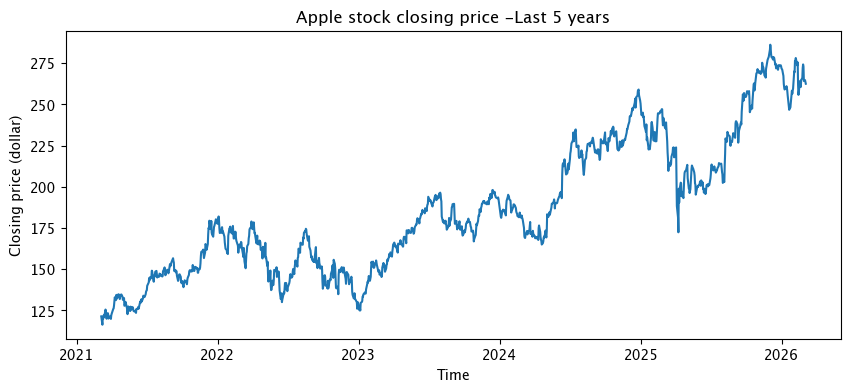

In [76]:
plt.figure(figsize =(10,4))
plt.plot(input_df['Close'])
plt.title('Apple stock closing price -Last 5 years')
plt.xlabel('Time')
plt.ylabel('Closing price (dollar)')
plt.show()

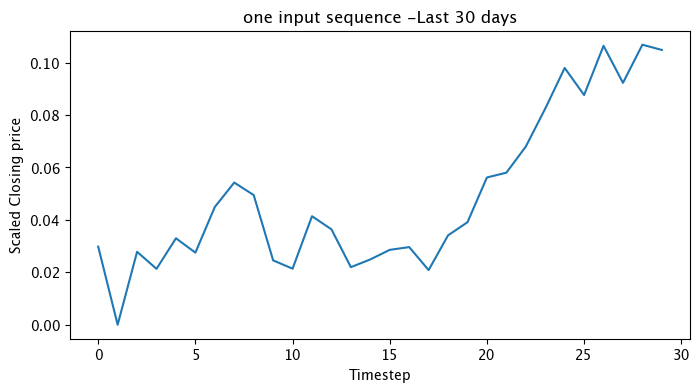

In [77]:
plt.figure(figsize =(8,4))
plt.plot(X[0])
plt.title('one input sequence -Last 30 days')
plt.xlabel('Timestep')
plt.ylabel('Scaled Closing price')
plt.show()

In [78]:
len(X[0])

30

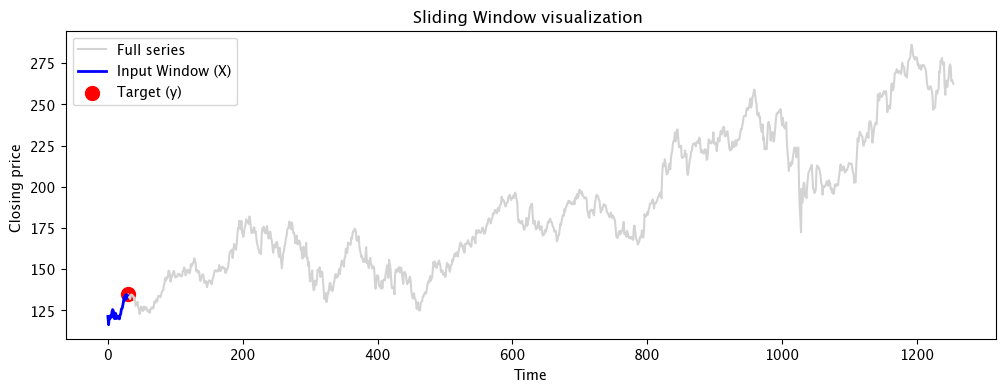

In [79]:
i=30

window_size=30

plt.figure(figsize =(12,4))
##full series 
plt.plot(input_df['Close'].values , color='lightgray',label ='Full series')
##sliding window (X)
plt.plot(range(i-window_size,i),input_df['Close'].values[i-window_size:i], color='blue',\
         linewidth=2,label ='Input Window (X)')

# target value (y)
plt.scatter(i,input_df['Close'].values[i],color ='red',s=100 , label ='Target (y)')
plt.title('Sliding Window visualization ')
plt.xlabel('Time')
plt.ylabel('Closing price ')
plt.legend()
plt.show()

In [80]:
##Vanilla RNN

model_rnn =Sequential([SimpleRNN(50 ,return_sequences=False ,input_shape =(window_size,1)),Dense(1)
                      ])

model_rnn.compile(optimizer ='adam' , loss='mse')
model_rnn.summary()

history_rnn = model_rnn.fit(X_train ,y_train , epochs =10 , batch_size =32 , validation_data =(X_test,y_test))

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_1 (SimpleRNN)    (None, 50)                2600      
                                                                 
 dense_1 (Dense)             (None, 1)                 51        
                                                                 
Total params: 2651 (10.36 KB)
Trainable params: 2651 (10.36 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
31/31 [==============================] - 6s 200ms/step - loss: 0.0133 - val_loss: 0.0032
Epoch 2/10
31/31 [==============================] - 6s 196ms/step - loss: 0.0011 - val_loss: 0.0036
Epoch 3/10
31/31 [==============================] - 6s 196ms/step - loss: 8.3278e-04 - val_loss: 0.0030
Epoch 4/10
31/31 [==============================] - 6s 195ms/step - loss: 7.8756e-04 - val_loss: 0.0033
Epoch 5/

In [81]:
prediction = model_rnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f"Predicted:{prediction[i][0]} , Actual : {actual[i][0]}")
    

8/8 [==============================] - 0s 28ms/step
Precited: 225.28668212890625 , Actual : 209.67999267578125
Precited: 219.4968719482422 , Actual : 213.49000549316406
Precited: 215.0846710205078 , Actual : 214.0
Precited: 213.77081298828125 , Actual : 212.6900177001953
Precited: 214.55496215820312 , Actual : 215.24000549316406
Precited: 214.87298583984375 , Actual : 214.09999084472656
Precited: 217.42393493652344 , Actual : 218.27000427246094
Precited: 218.32737731933594 , Actual : 220.72999572753906
Precited: 218.82057189941406 , Actual : 223.75
Precited: 222.26438903808594 , Actual : 221.52999877929688
Precited: 221.33456420898438 , Actual : 223.84999084472656
Precited: 224.48361206054688 , Actual : 217.89999389648438
Precited: 223.31370544433594 , Actual : 222.12998962402344
Precited: 224.17391967773438 , Actual : 223.19000244140625
Precited: 222.81105041503906 , Actual : 223.88999938964844
Precited: 224.75228881835938 , Actual : 203.19000244140625
Precited: 218.0936279296875 , Ac

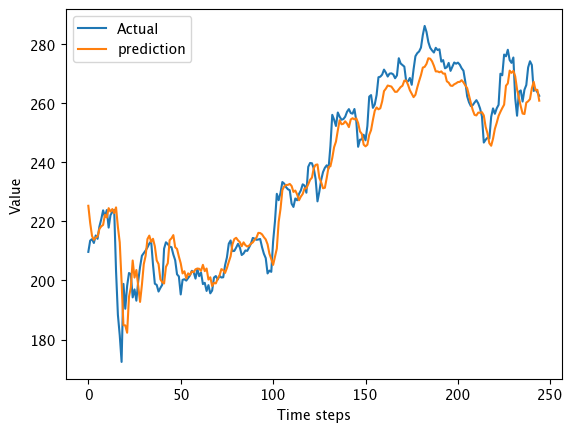

In [82]:
plt.figure()
plt.plot(actual , label ="Actual")
plt.plot(prediction , label ="prediction")
plt.xlabel("Time steps")
plt.ylabel("Value")
plt.legend()
plt.show()

In [84]:
## Deep /Stacked RNN


model_deep_rnn =Sequential([SimpleRNN(50 ,return_sequences=True ,input_shape =(window_size,1)),SimpleRNN(50),Dense(1)
                      ])

model_deep_rnn.compile(optimizer ='adam' , loss='mse')
model_deep_rnn.summary()

history_deep = model_deep_rnn.fit(X_train ,y_train , epochs =10 , batch_size =32 , validation_data =(X_test,y_test))

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_2 (SimpleRNN)    (None, 30, 50)            2600      
                                                                 
 simple_rnn_3 (SimpleRNN)    (None, 50)                5050      
                                                                 
 dense_2 (Dense)             (None, 1)                 51        
                                                                 
Total params: 7701 (30.08 KB)
Trainable params: 7701 (30.08 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
31/31 [==============================] - 19s 587ms/step - loss: 0.0287 - val_loss: 0.0065
Epoch 2/10
31/31 [==============================] - 18s 575ms/step - loss: 0.0016 - val_loss: 0.0035
Epoch 3/10
31/31 [==============================] - 18s 568ms/step - loss: 8.5946e

In [85]:
prediction = model_deep_rnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f"Predicted:{prediction[i][0]} , Actual : {actual[i][0]}")
    

8/8 [==============================] - 1s 56ms/step
Predicted:222.961181640625 , Actual : 209.67999267578125
Predicted:218.63363647460938 , Actual : 213.49000549316406
Predicted:217.78494262695312 , Actual : 214.0
Predicted:213.22250366210938 , Actual : 212.6900177001953
Predicted:214.37818908691406 , Actual : 215.24000549316406
Predicted:216.19651794433594 , Actual : 214.09999084472656
Predicted:215.79202270507812 , Actual : 218.27000427246094
Predicted:218.861328125 , Actual : 220.72999572753906
Predicted:218.89483642578125 , Actual : 223.75
Predicted:220.95301818847656 , Actual : 221.52999877929688
Predicted:222.42221069335938 , Actual : 223.84999084472656
Predicted:222.53927612304688 , Actual : 217.89999389648438
Predicted:221.14581298828125 , Actual : 222.12998962402344
Predicted:221.00363159179688 , Actual : 223.19000244140625
Predicted:221.63540649414062 , Actual : 223.88999938964844
Predicted:222.13963317871094 , Actual : 203.19000244140625
Predicted:217.27224731445312 , Actual

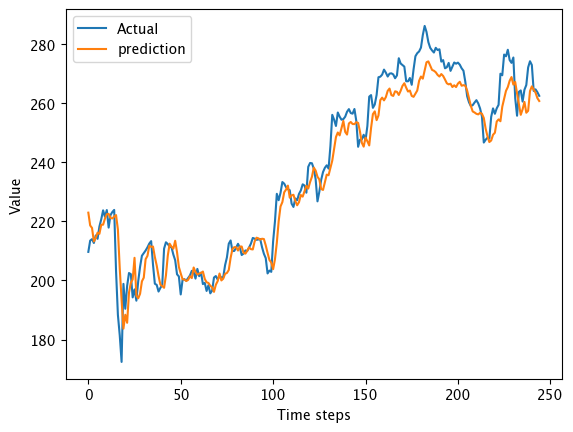

In [86]:
plt.figure()
plt.plot(actual , label ="Actual")
plt.plot(prediction , label ="prediction")
plt.xlabel("Time steps")
plt.ylabel("Value")
plt.legend()
plt.show()

In [89]:
##Bidirectional RNN
## Deep /Stacked RNN


model_bi_rnn =Sequential([Bidirectional(SimpleRNN(50),input_shape =(window_size,1)),Dense(1)
                      ])

model_bi_rnn.compile(optimizer ='adam' , loss='mse')
model_bi_rnn.summary()

history_bidir = model_bi_rnn.fit(X_train ,y_train , epochs =10 , batch_size =32 , validation_data =(X_test,y_test))


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 100)               5200      
 al)                                                             
                                                                 
 dense_3 (Dense)             (None, 1)                 101       
                                                                 
Total params: 5301 (20.71 KB)
Trainable params: 5301 (20.71 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/10
31/31 [==============================] - 13s 403ms/step - loss: 0.0420 - val_loss: 0.0267
Epoch 2/10
31/31 [==============================] - 12s 393ms/step - loss: 0.0036 - val_loss: 0.0062
Epoch 3/10
31/31 [==============================] - 13s 404ms/step - loss: 0.0019 - val_loss: 0.0054
Epoch 4/10
31/31 [=============================

In [90]:
prediction = model_bi_rnn.predict(X_test)
prediction = scaler.inverse_transform(prediction)

actual = scaler.inverse_transform(y_test)

for i in range(len(prediction)):
    print(f"Predicted:{prediction[i][0]} , Actual : {actual[i][0]}")
    

8/8 [==============================] - 1s 80ms/step
Predicted:234.63645935058594 , Actual : 209.67999267578125
Predicted:229.73863220214844 , Actual : 213.49000549316406
Predicted:226.3958282470703 , Actual : 214.0
Predicted:222.66673278808594 , Actual : 212.6900177001953
Predicted:221.7689666748047 , Actual : 215.24000549316406
Predicted:225.0352325439453 , Actual : 214.09999084472656
Predicted:218.36000061035156 , Actual : 218.27000427246094
Predicted:216.5967254638672 , Actual : 220.72999572753906
Predicted:219.5957489013672 , Actual : 223.75
Predicted:221.4478759765625 , Actual : 221.52999877929688
Predicted:223.24826049804688 , Actual : 223.84999084472656
Predicted:222.69229125976562 , Actual : 217.89999389648438
Predicted:222.44033813476562 , Actual : 222.12998962402344
Predicted:227.1821746826172 , Actual : 223.19000244140625
Predicted:225.7024383544922 , Actual : 223.88999938964844
Predicted:228.3113555908203 , Actual : 203.19000244140625
Predicted:221.16087341308594 , Actual :

In [105]:
##Stateful RNN
batch=32
model_stateful =Sequential([Input(batch_shape=(batch , window_size,1)),\
                    SimpleRNN(50 ,stateful=True),\
                    Dense(1)
                      ])

model_stateful.compile(optimizer ='adam' , loss='mse')
model_stateful.summary()



Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_7 (SimpleRNN)    (32, 50)                  2600      
                                                                 
 dense_6 (Dense)             (32, 1)                   51        
                                                                 
Total params: 2651 (10.36 KB)
Trainable params: 2651 (10.36 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [106]:
len(X_train) ,X_train.shape

(980, (980, 30, 1))

In [107]:
batch=32
train_len= len(X_train)-(len(X_train) % batch)
print(train_len)
X_train_s= X_train[:train_len]
y_train_s = y_train[:train_len]

print("Trimmed training shape", X_train_s.shape)

960
Trimmed training shape (960, 30, 1)


In [108]:
stateful_losses=[]
for epoch in range(10):
    print(f" Epoch :{epoch+1}")
    history = model_stateful.fit(X_train_s,y_train_s,batch_size=batch,epochs=1,shuffle=False)
#store losses
    stateful_losses.append(history.history['loss'][0])
    #reset rnn state after each epoch
    for layer in model_stateful.layers:
        if hasattr(layer ,"reset_states"):
            layer.reset_states()

 Epoch :1
30/30 [==============================] - 4s 140ms/step - loss: 0.0141
 Epoch :2
30/30 [==============================] - 4s 143ms/step - loss: 0.0112
 Epoch :3
30/30 [==============================] - 4s 138ms/step - loss: 0.0048
 Epoch :4
30/30 [==============================] - 4s 139ms/step - loss: 0.0025
 Epoch :5
30/30 [==============================] - 4s 141ms/step - loss: 0.0022
 Epoch :6
30/30 [==============================] - 4s 137ms/step - loss: 0.0016
 Epoch :7
30/30 [==============================] - 4s 139ms/step - loss: 0.0014
 Epoch :8
30/30 [==============================] - 4s 138ms/step - loss: 0.0013
 Epoch :9
30/30 [==============================] - 4s 142ms/step - loss: 0.0012
 Epoch :10
30/30 [==============================] - 4s 142ms/step - loss: 0.0011


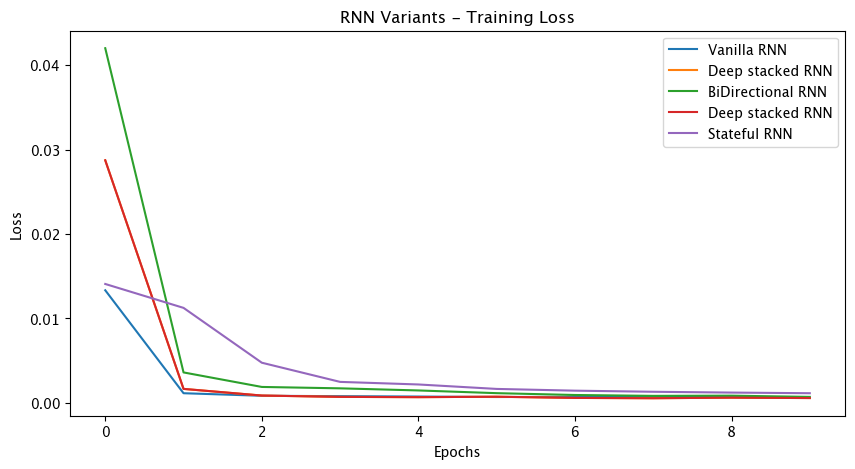

In [110]:
plt.figure(figsize =(10,5))
plt.plot(history_rnn.history['loss'], label='Vanilla RNN')
plt.plot(history_deep.history['loss'], label='Deep stacked RNN')
plt.plot(history_bidir.history['loss'], label='BiDirectional RNN')
plt.plot(history_deep.history['loss'], label='Deep stacked RNN')
plt.plot(stateful_losses, label='Stateful RNN')

plt.title('RNN Variants - Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()